In [1]:
import glob
import os
import json
import pandas as pd
from tqdm.auto import tqdm

# ────────────────────────────────────────────────
folder_path = '/kaggle/input/datasets/akshat3144/aug-to-may-comments'
jsonl_files = sorted(glob.glob(os.path.join(folder_path, '*.jsonl')))

print(f"Found {len(jsonl_files)} JSONL files:")
for f in jsonl_files:
    print("   ", os.path.basename(f))

# ────────────────────────────────────────────────
CHUNK_SIZE = 120_000           # ← lower to 80_000 or 50_000 if still OOM
output_csv = '/kaggle/working/all_comments_raw.csv'

all_chunks = []
total_rows = 0

for file_path in tqdm(jsonl_files, desc="Processing files"):
    print(f"  → {os.path.basename(file_path)}")
    
    chunk = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                record = json.loads(line)
                chunk.append(record)
                total_rows += 1
            except json.JSONDecodeError:
                continue  # skip broken lines
            
            if len(chunk) >= CHUNK_SIZE:
                df_chunk = pd.DataFrame(chunk)
                all_chunks.append(df_chunk)
                chunk = []  # free memory
    
    # last partial chunk of this file
    if chunk:
        all_chunks.append(pd.DataFrame(chunk))

# ────────────────────────────────────────────────
print("\nConcatenating all chunks...")
if all_chunks:
    df = pd.concat(all_chunks, ignore_index=True)
    print(f"Total rows collected: {len(df):,}")
    
    # Optional: convert object → string to save some memory
    for col in df.select_dtypes('object').columns:
        try:
            df[col] = df[col].astype('string[pyarrow_numpy]')
        except:
            pass
    
    print("Saving full CSV...")
    df.to_csv(output_csv, index=False)
    print(f"→ Saved: {output_csv} ({len(df):,} rows)")
else:
    print("No valid data found!")

Found 5 JSONL files:
    r_AskMiddleEast_comments.jsonl
    r_IsraelPalestine_comments.jsonl
    r_Israel_comments.jsonl
    r_IsrealPalestineWar_23_comments.jsonl
    r_Palestine_comments.jsonl


Processing files:   0%|          | 0/5 [00:00<?, ?it/s]

  → r_AskMiddleEast_comments.jsonl
  → r_IsraelPalestine_comments.jsonl
  → r_Israel_comments.jsonl
  → r_IsrealPalestineWar_23_comments.jsonl
  → r_Palestine_comments.jsonl

Concatenating all chunks...


/tmp/ipykernel_55/2315741277.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(all_chunks, ignore_index=True)


Total rows collected: 3,083,006


/tmp/ipykernel_55/2315741277.py:56: FutureWarning: The 'pyarrow_numpy' storage option name is deprecated and will be removed in pandas 3.0. Use 'pd.StringDtype(storage="pyarrow", na_value-np.nan)' to construct the same dtype.
Or enable the 'pd.options.future.infer_string = True' option globally and use the "str" alias as a shorthand notation to specify a dtype (instead of "string[pyarrow_numpy]").
  df[col] = df[col].astype('string[pyarrow_numpy]')
/tmp/ipykernel_55/2315741277.py:56: FutureWarning: The 'pyarrow_numpy' storage option name is deprecated and will be removed in pandas 3.0. Use 'pd.StringDtype(storage="pyarrow", na_value-np.nan)' to construct the same dtype.
Or enable the 'pd.options.future.infer_string = True' option globally and use the "str" alias as a shorthand notation to specify a dtype (instead of "string[pyarrow_numpy]").
  df[col] = df[col].astype('string[pyarrow_numpy]')
/tmp/ipykernel_55/2315741277.py:56: FutureWarning: The 'pyarrow_numpy' storage option name is 

Saving full CSV...
→ Saved: /kaggle/working/all_comments_raw.csv (3,083,006 rows)


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/working/all_comments_raw.csv', low_memory=False)

total_rows = len(df)
print(f"Total rows: {total_rows:,}\n")

print("Null percentage per column:")
for col in df.columns:
    null_cnt = df[col].isna().sum()
    null_pct = null_cnt / total_rows * 100
    print(f"{col:.<35} {null_pct:6.2f}%")

Total rows: 3,083,006

Null percentage per column:
_meta..............................   0.33%
all_awardings......................   0.00%
approved_at_utc.................... 100.00%
approved_by........................ 100.00%
archived...........................   0.00%
associated_award................... 100.00%
author.............................   0.00%
author_flair_background_color......  84.71%
author_flair_css_class.............  93.72%
author_flair_richtext..............   5.55%
author_flair_template_id...........  82.92%
author_flair_text..................  82.64%
author_flair_text_color............  72.00%
author_flair_type..................   5.55%
author_fullname....................   5.55%
author_is_blocked..................   0.00%
author_patreon_flair...............   5.55%
author_premium.....................   5.55%
awarders...........................   0.00%
banned_at_utc...................... 100.00%
banned_by.......................... 100.00%
body.....................

In [3]:
import pandas as pd

# df = pd.read_csv('/kaggle/working/all_comments_raw.csv', low_memory=False)

null_percent = df.isna().mean() * 100
cols_to_keep = null_percent[null_percent < 6].index.tolist()

print(f"Original columns : {df.shape[1]}")
print(f"Kept columns     : {len(cols_to_keep)} (<6% null)")

df_filtered = df[cols_to_keep].copy()

# Try to save some memory
for col in df_filtered.select_dtypes('object').columns:
    try:
        df_filtered[col] = df_filtered[col].astype('string[pyarrow_numpy]')
    except:
        pass

Original columns : 76
Kept columns     : 45 (<6% null)


/tmp/ipykernel_55/3032345192.py:16: FutureWarning: The 'pyarrow_numpy' storage option name is deprecated and will be removed in pandas 3.0. Use 'pd.StringDtype(storage="pyarrow", na_value-np.nan)' to construct the same dtype.
Or enable the 'pd.options.future.infer_string = True' option globally and use the "str" alias as a shorthand notation to specify a dtype (instead of "string[pyarrow_numpy]").
  df_filtered[col] = df_filtered[col].astype('string[pyarrow_numpy]')
/tmp/ipykernel_55/3032345192.py:16: FutureWarning: The 'pyarrow_numpy' storage option name is deprecated and will be removed in pandas 3.0. Use 'pd.StringDtype(storage="pyarrow", na_value-np.nan)' to construct the same dtype.
Or enable the 'pd.options.future.infer_string = True' option globally and use the "str" alias as a shorthand notation to specify a dtype (instead of "string[pyarrow_numpy]").
  df_filtered[col] = df_filtered[col].astype('string[pyarrow_numpy]')
/tmp/ipykernel_55/3032345192.py:16: FutureWarning: The 'py

In [4]:
output_filtered = '/kaggle/working/reddit_comments_filtered.csv'
df_filtered.to_csv(output_filtered, index=False)
print(f"\nFiltered dataset saved → {output_filtered}")


Filtered dataset saved → /kaggle/working/reddit_comments_filtered.csv


====================

/tmp/ipykernel_55/2229821386.py:4: DtypeWarning: Columns (13,19,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/working/reddit_comments_filtered.csv')


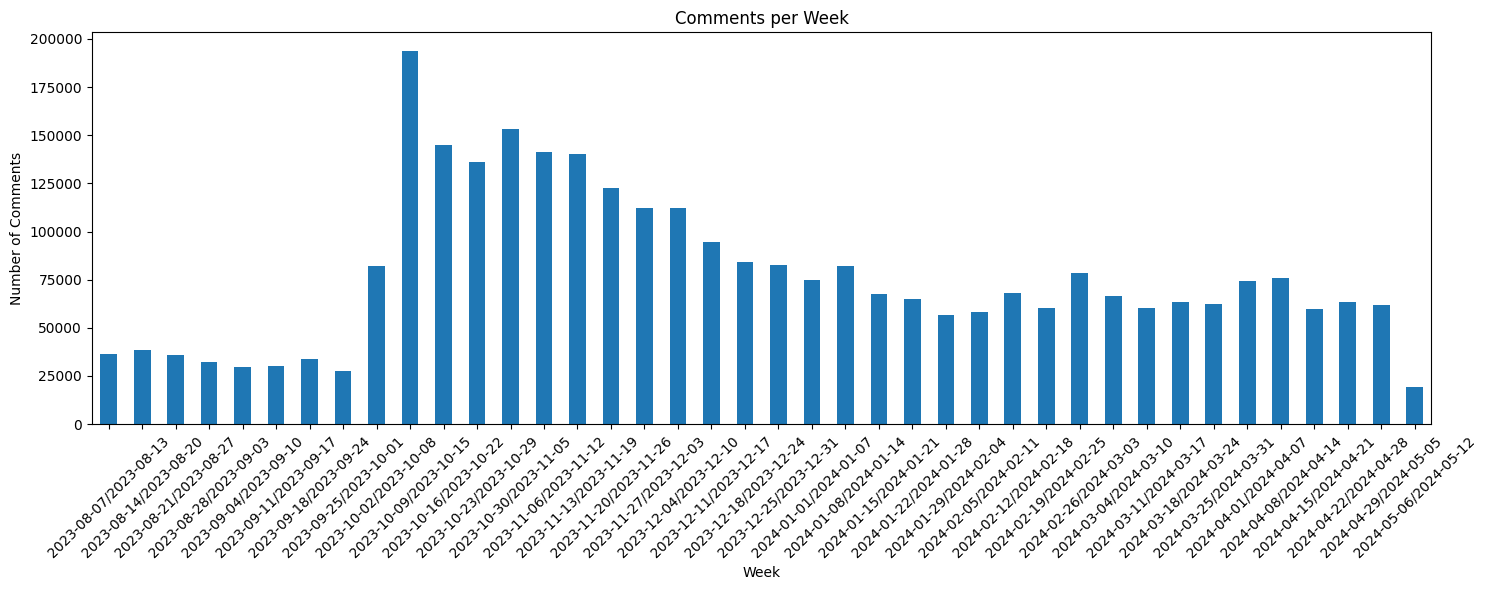

Total posts: 3083006
Date range: 2023-08-07 00:00:27 to 2024-05-07 23:59:58


In [8]:
import matplotlib.pyplot as plt

# Load cleaned CSV
df = pd.read_csv('/kaggle/working/reddit_comments_filtered.csv')

# Convert timestamp to datetime
df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s')

# Create week column
df['week'] = df['created_utc'].dt.to_period('W')

# Group by week
posts_per_week = df.groupby('week').size()

# Plot
plt.figure(figsize=(15, 6))
posts_per_week.plot(kind='bar')
plt.title('Comments per Week')
plt.xlabel('Week')
plt.ylabel('Number of Comments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Total posts: {len(df)}")
print(f"Date range: {df['created_utc'].min()} to {df['created_utc'].max()}")

AskMiddleEast: 787986 posts, Date range: 2023-08-07 00:00:27 to 2024-05-07 23:59:16
Israel: 571397 posts, Date range: 2023-08-07 00:00:45 to 2024-05-07 23:59:58
IsraelPalestine: 1227359 posts, Date range: 2023-08-07 00:41:15 to 2024-05-07 23:58:35
IsrealPalestineWar_23: 40919 posts, Date range: 2023-10-07 18:52:10 to 2024-05-07 23:57:56
Palestine: 455345 posts, Date range: 2023-10-07 00:10:05 to 2024-05-07 23:55:08

Plot saved to: /kaggle/working/posts_per_week_by_subreddit.png


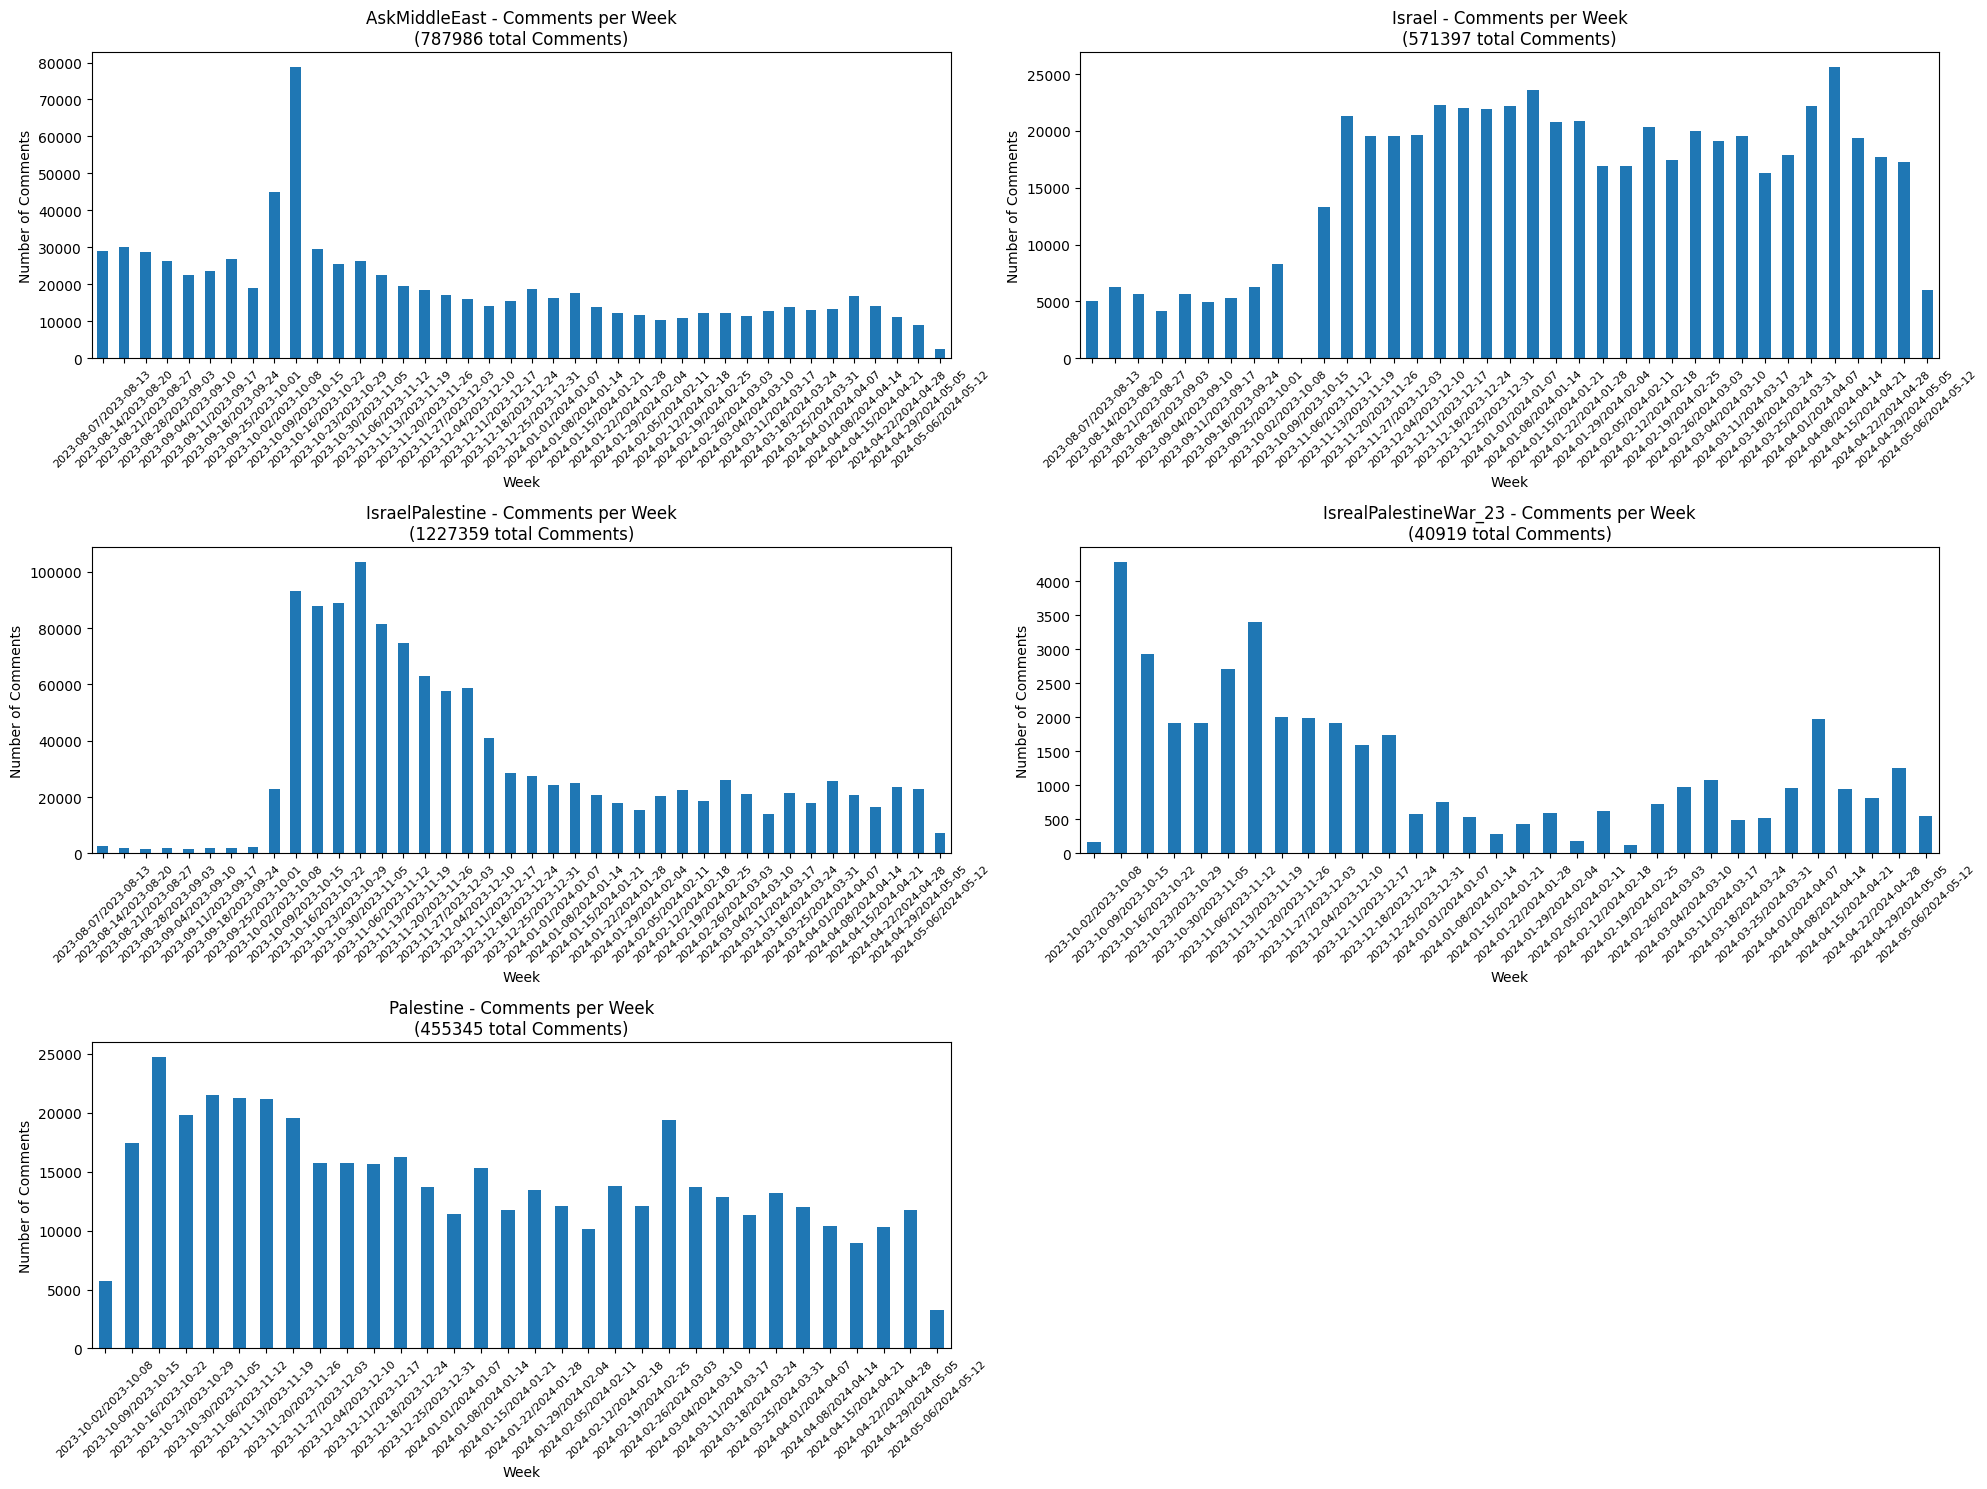

In [9]:
import math

# Load CSV
# df = pd.read_csv('/kaggle/working/reddit_posts.csv')

# Convert timestamp
df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s')

# Create week column
df['week'] = df['created_utc'].dt.to_period('W')

# Get unique subreddits
subreddits = df['subreddit'].unique()
n_files = len(subreddits)

# Grid size
n_cols = 2
n_rows = math.ceil(n_files / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

# Plot each subreddit
for idx, subreddit in enumerate(sorted(subreddits)):
    
    df_sub = df[df['subreddit'] == subreddit]
    
    posts_per_week = df_sub.groupby('week').size()
    
    ax = axes[idx]
    posts_per_week.plot(kind='bar', ax=ax)
    
    ax.set_title(f'{subreddit} - Comments per Week\n({len(df_sub)} total Comments)', fontsize=12)
    ax.set_xlabel('Week', fontsize=10)
    ax.set_ylabel('Number of Comments', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    print(f"{subreddit}: {len(df_sub)} posts, "
          f"Date range: {df_sub['created_utc'].min()} to {df_sub['created_utc'].max()}")

# Hide unused subplots
for idx in range(n_files, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()

# Save image
output_image = '/kaggle/working/posts_per_week_by_subreddit.png'
plt.savefig(output_image, dpi=300, bbox_inches='tight')

print(f"\nPlot saved to: {output_image}")

plt.show()